This notebook contains the code to perform segmentation of cave paintings using morphological geodesic active contours. The parameters that are used are those which have been empirically proven the best : num_iter=500 and threshold=0.75.

### Useful functions and imports

In [20]:
import numpy as np
import cv2
import skimage as ski
from skimage.segmentation import morphological_geodesic_active_contour
from skimage.filters import sobel, gaussian
from skimage.measure import find_contours
from skimage.segmentation import inverse_gaussian_gradient
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from skimage.morphology import remove_small_objects
import os

In [2]:
def convert_color_space(img, color_space):
    if color_space == "rgb":
        return img
    if color_space == "gray":
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if color_space == "hsv":
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    if color_space == "lab":
        return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    raise ValueError(color_space)

def equalize_image(img):
    if img.ndim == 2:
        return cv2.equalizeHist(img)
    ch = cv2.split(img)
    ch = [cv2.equalizeHist(c) for c in ch]
    return cv2.merge(ch)

def clahe_image(img, clip=2.0, grid=(8,8)):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    if img.ndim == 2:
        return clahe.apply(img)
    ch = cv2.split(img)
    ch = [clahe.apply(c) for c in ch]
    return cv2.merge(ch)

def preprocess_charcoal_image(img):
    out = convert_color_space(img, "lab")
    out = clahe_image(out)
    return out

In [3]:
def denoise(img, method=None, g_sigma=1.0, m_ksize=5):
    if method is None:
        return img
    if method == "gaussian":
        k = int(g_sigma*6+1)|1
        return cv2.GaussianBlur(img,(k,k),g_sigma)
    if method == "median":
        if m_ksize % 2 == 0:
            m_ksize += 1
        return cv2.medianBlur(img, m_ksize)
    raise ValueError(method)

In [4]:
def region_boundaries(labels):
    h, w = labels.shape
    boundaries = np.zeros((h, w), dtype=np.uint8)
    for y in range(h - 1):
        for x in range(w - 1):
            if labels[y, x] != labels[y, x + 1] or labels[y, x] != labels[y + 1, x]:
                boundaries[y, x] = 255
    return boundaries

In [13]:
def store_evolution_in(lst):
    """Returns a callback function to store the evolution of the level sets in
    the given list.
    """

    def _store(x):
        lst.append(np.copy(x))

    return _store

def apply_active_contours(img, num_iter=500, threshold=0.75):

    img=img[:,:,0]
    
    img = ski.util.img_as_float(img)

    gimage = ski.segmentation.inverse_gaussian_gradient(img)

    init_ls = np.zeros(img.shape[:2], dtype=np.int8)
    init_ls[10:-10, 10:-10] = 1

    evolution = []
    callback = store_evolution_in(evolution)
    snake_mask = ski.segmentation.morphological_geodesic_active_contour(
        gimage,
        num_iter=num_iter,
        init_level_set=init_ls,
        smoothing=1,
        balloon=-1,
        threshold=threshold,#0.69
        iter_callback=callback,
    )

    return snake_mask, evolution

In [14]:
def preprocess_img(img_path, x1,y1,x2,y2):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cropped_img = img_rgb[y1:y2, x1:x2]
    preprocessed_img = preprocess_charcoal_image(cropped_img)
    # preprocessed_img = preprocessed_img[:,:,0].astype(np.float32) / 255.0
    # img_smooth = gaussian(preprocessed_img, sigma=1)
    # return img_smooth
    return preprocessed_img

In [15]:
def evaluate_active_contours_params(imgs_path_list, crops_coordinates_list, num_iter_colors_list, threshold_list, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    max_iter = max(num_iter_colors_list, key=lambda x: x[0])[0]

    for i, img_path in enumerate(imgs_path_list):

        print(f"Processing image {img_path}")

        img_name = os.path.splitext(os.path.basename(img_path))[0]
        img_out_dir = os.path.join(output_dir, f"{img_name}")
        os.makedirs(img_out_dir, exist_ok=True)

        x1, y1, x2, y2 = crops_coordinates_list[i]
        img = preprocess_img(img_path, x1, y1, x2, y2)

        for th in threshold_list:
            print(f"threshold={th}")
            snake_mask, evolution = apply_active_contours(img, num_iter=max_iter, threshold=th)
            
            plt.figure()
            plt.imshow(img, cmap='gray')

            legend_handles = []

            # Plot multiple contours
            for num_iter, color in num_iter_colors_list:

                if num_iter < len(evolution):
                    plt.contour(
                        evolution[num_iter],
                        levels=[0.5],
                        colors=color
                    )
                    
                    legend_handles.append(
                        Line2D(
                            [0], [0],
                            color=color,
                            lw=2,
                            label=f"Iter {num_iter}"
                        )
                    )

            plt.legend(handles=legend_handles, loc="upper right")
            plt.axis("off")

            # Save figure
            filename = f"ac_threshold{th}.png"
            save_path = os.path.join(img_out_dir, filename)

            plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
            plt.close()

In [206]:
imgs_path_list=['../dataset/cosquer/panneau_des_cheveaux.jpg', '../dataset/mains/Cueva_de_las_manos_-_detalle.jpg', '../dataset/lascaux/Lascaux_021.jpg']
crops_coordinates_list=[[100,375,543,682],[955,548,1153,734],[402,198,923,669]]
num_iter_colors_list=[(0, 'red'), (100, 'orange'), (200, 'yellow'), (300, 'green'), (500, 'blue')]
threshold_list=[0.6,0.65,0.7,0.75,0.8,0.85,0.9, 'auto']
output_dir="active_contours_results"

evaluate_active_contours_params(imgs_path_list,crops_coordinates_list, num_iter_colors_list, threshold_list, output_dir)

Processing image ../dataset/cosquer/panneau_des_cheveaux.jpg
threshold=0.6
threshold=0.65
threshold=0.7
threshold=0.75
threshold=0.8
threshold=0.85
threshold=0.9
threshold=auto
Processing image ../dataset/mains/Cueva_de_las_manos_-_detalle.jpg
threshold=0.6
threshold=0.65
threshold=0.7
threshold=0.75
threshold=0.8
threshold=0.85
threshold=0.9
threshold=auto
Processing image ../dataset/lascaux/Lascaux_021.jpg
threshold=0.6
threshold=0.65
threshold=0.7
threshold=0.75
threshold=0.8
threshold=0.85
threshold=0.9
threshold=auto


In [33]:
def show_contour(img, snake_mask, save_path=None):
    plt.figure()
    plt.imshow(img[:,:,0], cmap='gray')
    plt.contour(snake_mask, [0.5], colors='r')
    # plt.title("Active Contour")
    plt.axis('off')
    if save_path is not None:
        plt.savefig(save_path + '_filtered_active_contours.png',
                    bbox_inches='tight',
                    pad_inches=0,
                    dpi=300)
    plt.show()

### Filtering and segmenting the interior of the contour

In [25]:
def create_segmentation_results(snake_mask, img, save_path=None, alpha=0.5):
    # Ensure mask is boolean
    mask = snake_mask.astype(bool)

    # Convert original image (LAB → RGB)
    original_rgb = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
    overlay = original_rgb.copy()

    # Green overlay color
    green = np.array([0, 255, 0], dtype=np.uint8)

    # Apply transparent overlay
    overlay[mask] = (
        (1 - alpha) * overlay[mask] +
        alpha * green
    ).astype(np.uint8)

    # Plot and save
    plt.figure(figsize=(10, 8))
    plt.imshow(overlay)
    plt.axis("off")

    if save_path is not None:
        plt.savefig(save_path + '_segmentation_results.png',
                    bbox_inches='tight',
                    pad_inches=0,
                    dpi=300)
    plt.show()
    plt.close()

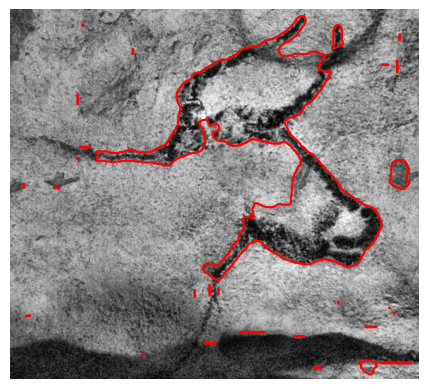

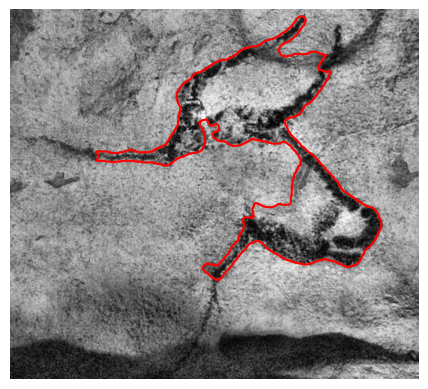

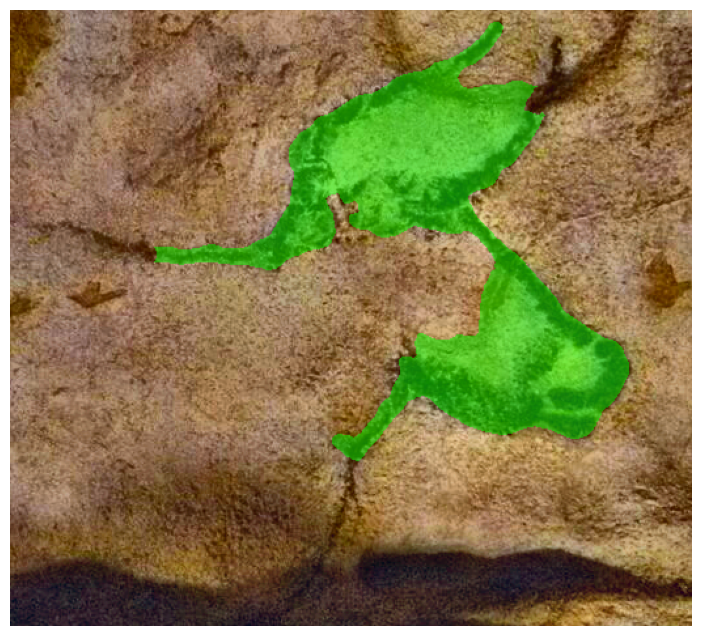

In [34]:
img=preprocess_img('../dataset/lascaux/Lascaux_021.jpg', 402,198,923,669)

snake_mask, evolution=apply_active_contours(img)
show_contour(img, snake_mask)

h,w=snake_mask.shape
snake_mask_filtered = remove_small_objects(snake_mask.astype(bool), min_size=h*w/100)
show_contour(img, snake_mask_filtered, save_path='active_contours_results/lascaux')

create_segmentation_results(snake_mask_filtered, img, save_path='active_contours_results/lascaux')

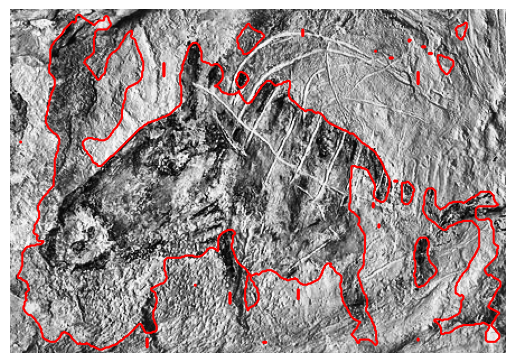

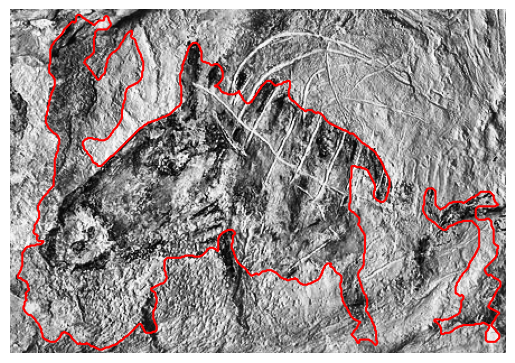

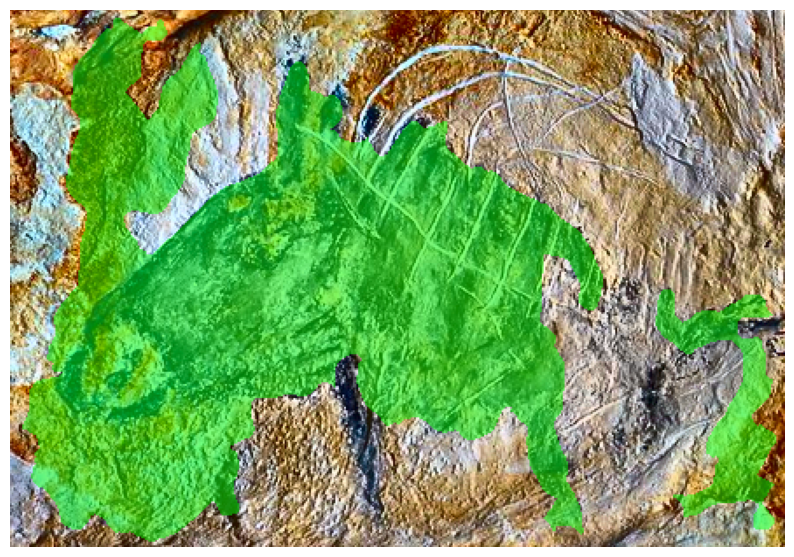

In [35]:
img=preprocess_img('../dataset/cosquer/panneau_des_cheveaux.jpg', 100,375,543,682)

snake_mask, evolution=apply_active_contours(img)
show_contour(img, snake_mask)

h,w=snake_mask.shape
snake_mask_filtered = remove_small_objects(snake_mask.astype(bool), min_size=h*w/100)
show_contour(img, snake_mask_filtered, save_path='active_contours_results/cosquer')

create_segmentation_results(snake_mask_filtered, img, save_path='active_contours_results/cosquer')

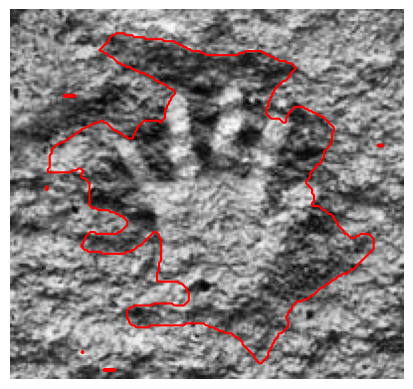

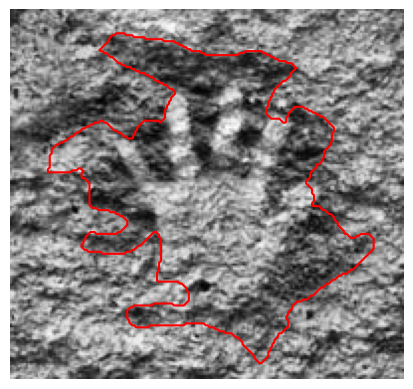

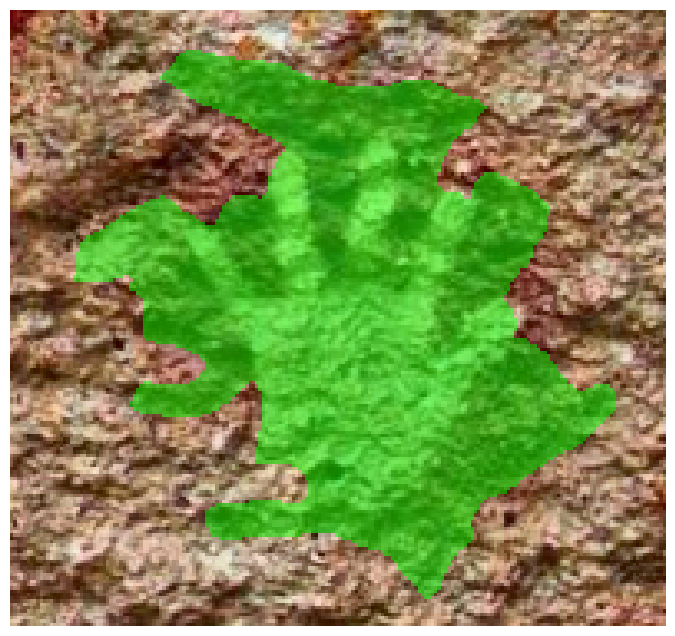

In [36]:
img=preprocess_img('../dataset/mains/Cueva_de_las_manos_-_detalle.jpg', 955,548,1153,734)

snake_mask, evolution=apply_active_contours(img)
show_contour(img, snake_mask)

h,w=snake_mask.shape
snake_mask_filtered = remove_small_objects(snake_mask.astype(bool), min_size=h*w/100)
show_contour(img, snake_mask_filtered, save_path='active_contours_results/mains')

create_segmentation_results(snake_mask_filtered, img, save_path='active_contours_results/mains')

### trash

(186, 198)


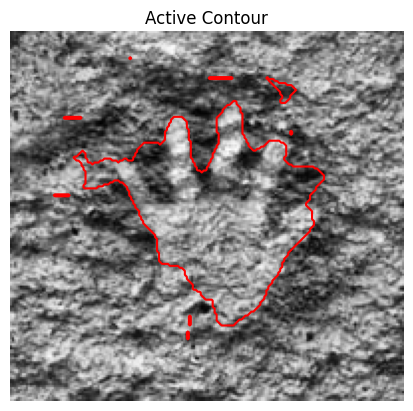

In [113]:
import skimage as ski
img=preprocess_img('../dataset/lascaux/Lascaux_021.jpg', 402,198,923,669)
# img=preprocess_img('../dataset/cosquer/panneau_des_cheveaux.jpg', 100,375,543,682)
img=preprocess_img('../dataset/mains/Cueva_de_las_manos_-_detalle.jpg', 955,548,1153,734)
img = ski.util.img_as_float(img)

gimage = ski.segmentation.inverse_gaussian_gradient(img)

init_ls = np.zeros(img.shape[:2], dtype=np.int8)
init_ls[10:-10, 10:-10] = 1

ls = ski.segmentation.morphological_geodesic_active_contour(
    gimage,
    num_iter=80,
    init_level_set=init_ls,
    smoothing=1,
    balloon=-1,
    threshold=0.69
)

print(img.shape)
show_contour(img, ls)

### Suite

In [7]:
def evaluate_meanshift_params(imgs_path_list, crops_coordinates_list, ks_range, kr_range, output_dir):
    
    os.makedirs(output_dir, exist_ok=True)

    for i, img_path in enumerate(imgs_path_list):

        print(f"Processing image {img_path}")

        img_name = os.path.splitext(os.path.basename(img_path))[0]
        img_out_dir = os.path.join(output_dir, f"{img_name}")
        os.makedirs(img_out_dir, exist_ok=True)

        x1, y1, x2, y2 = crops_coordinates_list[i]
        img = preprocess_img(img_path, x1, y1, x2, y2)
        img=denoise(img, method="median", m_ksize=2)

        h, w, _ = img.shape
        ks_range=np.array(ks_range)*((h*w)/68000)

        for ks in ks_range:
            for kr in kr_range:
                print(f"ks={ks}, kr={kr}")
                segmented, result, nb_regions = apply_meanshift(img, spatial_radius=ks, color_radius=kr)
                filename = f"ms_ks{int(ks)}_kr{int(kr)}_{nb_regions}regions.png"
                save_path = os.path.join(img_out_dir, filename)
                segmented_bgr = cv2.cvtColor(segmented, cv2.COLOR_LAB2BGR)
                cv2.imwrite(save_path, segmented_bgr)

In [9]:
imgs_path_list=['../dataset/cosquer/panneau_des_cheveaux.jpg', '../dataset/mains/Cueva_de_las_manos_-_detalle.jpg'] #[ '../dataset/lascaux/Lascaux_021.jpg']
crops_coordinates_list=[[100,375,543,682],[955,548,1153,734]]#[100,375,543,682],[955,548,1153,734],[402,198,923,669]
ks_range=[16,24,32,40,48]
kr_range=[8,16,24,32,40,48]
output_dir="meanshift_results"

evaluate_meanshift_params(imgs_path_list,crops_coordinates_list, ks_range, kr_range, output_dir)

Processing image ../dataset/cosquer/panneau_des_cheveaux.jpg
ks=32.000235294117644, kr=8
3243 different regions
ks=32.000235294117644, kr=16
417 different regions
ks=32.000235294117644, kr=24
152 different regions
ks=32.000235294117644, kr=32
96 different regions
ks=32.000235294117644, kr=40
71 different regions
ks=32.000235294117644, kr=48
56 different regions
ks=48.000352941176466, kr=8
1800 different regions
ks=48.000352941176466, kr=16
165 different regions
ks=48.000352941176466, kr=24
67 different regions
ks=48.000352941176466, kr=32
38 different regions
ks=48.000352941176466, kr=40
31 different regions
ks=48.000352941176466, kr=48
22 different regions
ks=64.00047058823529, kr=8
1144 different regions
ks=64.00047058823529, kr=16
82 different regions
ks=64.00047058823529, kr=24
35 different regions
ks=64.00047058823529, kr=32
18 different regions
ks=64.00047058823529, kr=40
15 different regions
ks=64.00047058823529, kr=48
11 different regions
ks=80.00058823529412, kr=8
794 differen

#### Meanshift, brouillon

In [132]:
preprocessed_img=preprocess_img("../dataset/cosquer/panneau_des_cheveaux.jpg", 100, 375, 543, 682)
# preprocessed_img=cv2.resize(preprocessed_img, (443//2, 307//2))
preprocessed_img=denoise(preprocessed_img, method="median", m_ksize=2)

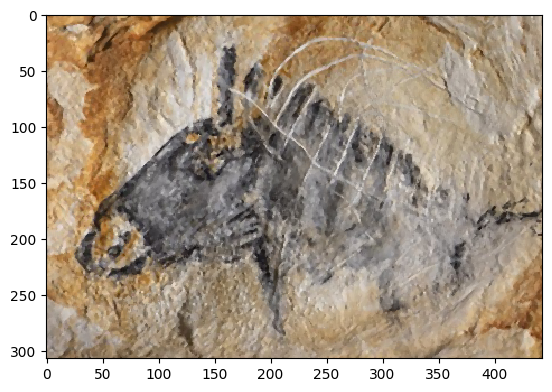

In [133]:
# rgb = cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB)
rgb=preprocessed_img
plt.imshow(rgb,interpolation='nearest')
plt.show()

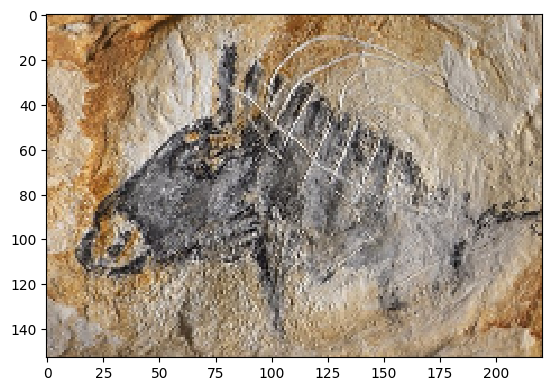

In [127]:
# rgb = cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB)
rgb=preprocessed_img
plt.imshow(rgb,interpolation='nearest')
plt.show()

In [128]:
segmented, result = apply_meanshift(preprocessed_img, spatial_radius=40, color_radius=40)

9 different regions


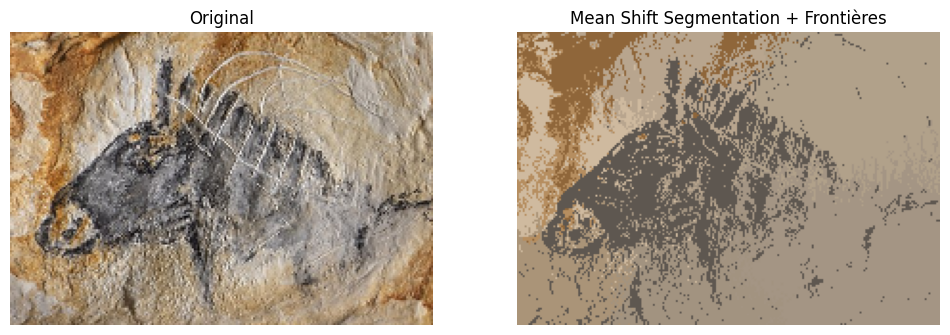

In [129]:
# result_rgb = cv2.cvtColor(result, cv2.COLOR_LAB2RGB)
# segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_LAB2RGB)
result_rgb=result
segmented_rgb=segmented
preprocessed_img_rgb = cv2.cvtColor(preprocessed_img, cv2.COLOR_LAB2RGB)
preprocessed_img_rgb = preprocessed_img
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(preprocessed_img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented_rgb)
plt.title("Mean Shift Segmentation + Frontières")
plt.axis('off')

plt.show()

### Morphological Geodesic Active Contours

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.filters import gaussian, sobel
from skimage.segmentation import morphological_geodesic_active_contour
from skimage.draw import polygon
from scipy.interpolate import splprep, splev
from skimage.measure import find_contours
from skimage.segmentation import inverse_gaussian_gradient

In [ ]:
preprocessed_img=preprocess_img("../dataset/cosquer/panneau_des_cheveaux.jpg", 100, 375, 543, 682)
# preprocessed_img=cv2.resize(preprocessed_img, (443//2, 307//2))
preprocessed_img=denoise(preprocessed_img, method="median", m_ksize=2)

In [ ]:
gimage = inverse_gaussian_gradient(preprocessed_img)
init_ls = np.zeros(preprocessed_img.shape, dtype=np.int8)
init_ls[10:-10, 10:-10] = 1

snake_mask = morphological_geodesic_active_contour(
    gimage,
    num_iter=230,
    init_level_set=init_ls,
    smoothing=1,
    balloon=-1
)

contours = find_contours(snake_mask, level=0.5)
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(cv2.cvtColor(preprocessed_img, cv2.COLOR_LAB2RGB))
for contour in contours:
    ax.plot(contour[:,1], contour[:,0], '-b', lw=2)
ax.set_title("MGAC après preprocessing")
ax.axis('off')
plt.show()